# Inspecting Temperature and Chemistry Profiles

The [Transmission spectrum basics](https://escience-taurex.github.io/taurex3/examples/03_transmission_basics.html) and [Emission spectrum basics](https://escience-taurex.github.io/taurex3/examples/04_emission_basics.html) walkthroughs produced spectra; the emission example used an isothermal temperature profile and the result was a relatively featureless thermal emission curve. This notebook goes one level deeper and looks at the vertical structure sitting behind every spectrum. Understanding these profiles is essential for interpreting model outputs, and [Contribution analysis](https://escience-taurex.github.io/taurex3/examples/07_contribution_analysis.html) builds directly on the intuition developed here.

The vertical temperature and composition profiles determine what the spectrum encodes. A temperature inversion turns absorption features into emission peaks. A gradient in mixing ratio can mimic or mask a spectral signal from a different gas. Plotting these profiles alongside the spectrum is the most direct path from model output to physical understanding.

This example uses a `Guillot2010` temperature profile, which produces a physically realistic lapse rate with an optional stratospheric inversion. More information about temperature profiles is [here](../user/taurex/temperature.rst), chemistry options are [here](../user/taurex/chemistry.rst), and model-derived quantities are [here](../user/taurex/derived.rst).

## Data Note

This notebook uses the opacity files set up in [Setup and opacity data](https://escience-taurex.github.io/taurex3/examples/01_setup_and_data.html). TauREx provides the software to work with these datasets; the files themselves are third-party products from [ExoMol](https://www.exomol.com).

In [1]:
from _shared import build_emission_model
from taurex.temperature import Guillot2010

temperature_profile = Guillot2010(T_irr=1500)
context = build_emission_model(temperature_profile=temperature_profile, download=False)
temperature_profile.initialize_profile(
    planet=context['planet'],
    nlayers=context['press'].nLayers,
    pressure_profile=context['press'].profile,
)
em = context['em']

print(type(temperature_profile).__name__)
print('Gases:', em.chemistry.gases)

Guillot2010
Gases: ['H2', 'He', 'H2O', 'CH4', 'NH3', 'CO2']


## Temperature Profile

The T–P profile governs which pressure levels contribute most to the emergent spectrum. In an emission model, layers where the temperature gradient is steepest imprint the strongest molecular features — an inversion can turn an absorption line into an emission peak. Even without an inversion, a realistic lapse rate produces noticeably more structured spectra than the isothermal baseline in [Emission spectrum basics](https://escience-taurex.github.io/taurex3/examples/04_emission_basics.html).

More information about temperature profile families and their parameters is [here](../user/taurex/temperature.rst).

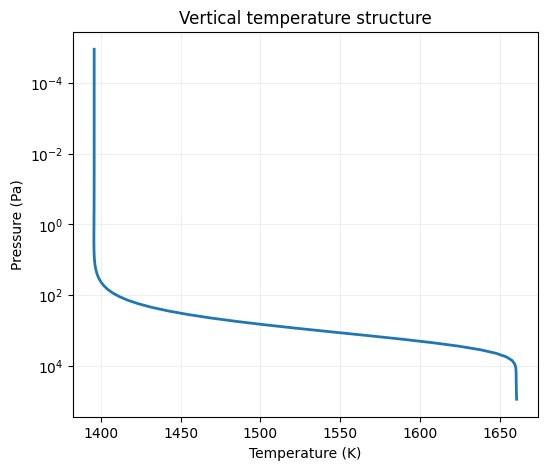

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.plot(em.temperatureProfile, em.pressureProfile, lw=2)
plt.gca().invert_yaxis()
plt.yscale('log')
plt.xlabel('Temperature (K)')
plt.ylabel('Pressure (Pa)')
plt.title('Vertical temperature structure')
plt.grid(alpha=0.2)

## Chemical Mixing-Ratio Profiles

Knowing the temperature profile alone is not enough — we also need to know which gases are present at each altitude. Plotting the volume mixing ratio (VMR) of each species against pressure shows which absorbers are available at depth. For a uniform (constant-with-altitude) chemistry, all gas profiles are flat; other chemistry models can introduce vertical gradients that reshape individual spectral features.

Temperature range: 1395.7 K to 1660.4 K


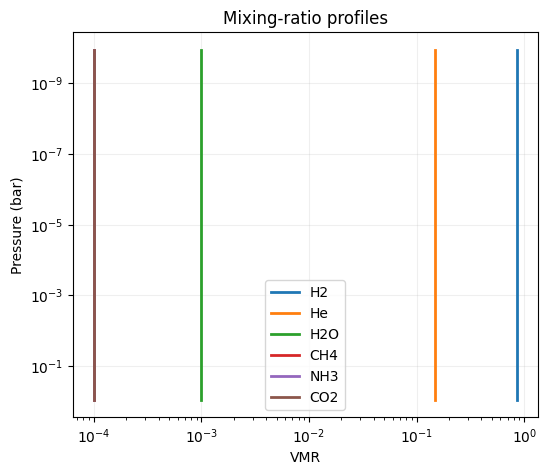

In [3]:
plt.figure(figsize=(6, 5))
for index, gas_name in enumerate(em.chemistry.gases):
    plt.plot(em.chemistry.mixProfile[index], em.pressureProfile / 1e5, label=gas_name, lw=2)
plt.gca().invert_yaxis()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('VMR')
plt.ylabel('Pressure (bar)')
plt.title('Mixing-ratio profiles')
plt.legend()
plt.grid(alpha=0.2)

print(f'Temperature range: {em.temperatureProfile.min():.1f} K to {em.temperatureProfile.max():.1f} K')

## Derived Quantities

The model also computes several derived profiles: number density, altitude above the reference pressure level, and layer-by-layer mean molecular weight. These are useful both as sanity checks — does the scale height match expectations for the assumed temperature and mean molecular weight? — and as physical inputs for post-processing workflows.

More derived quantities are documented [here](../user/taurex/derived.rst).

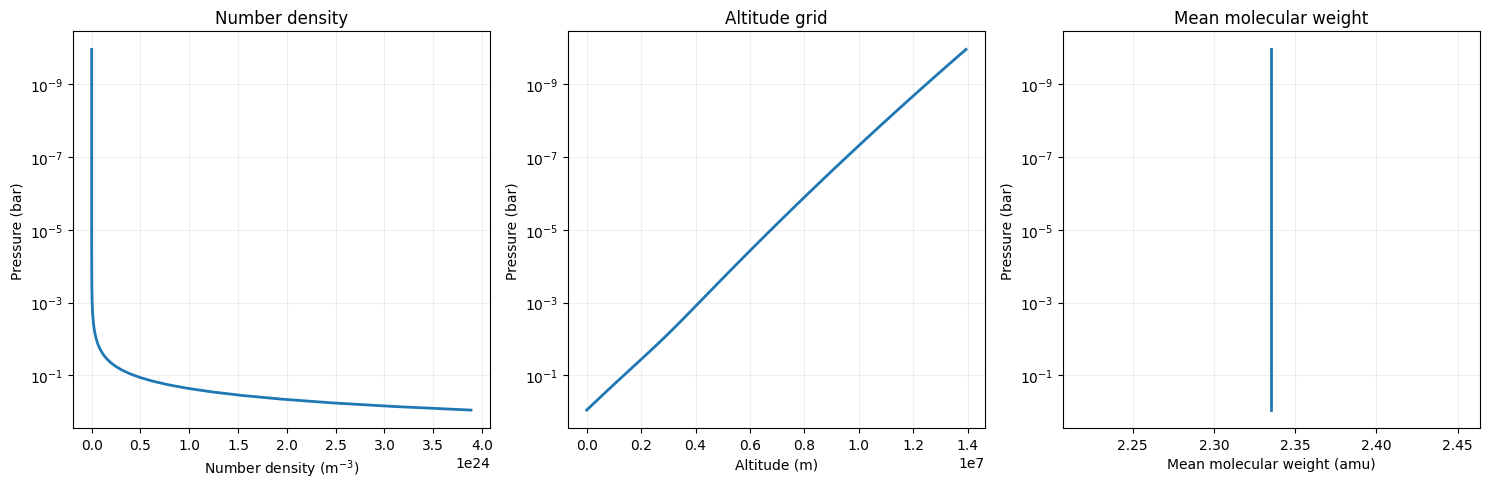

In [4]:
from taurex.constants import AMU

em.initialize_profiles()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(em.densityProfile, em.pressureProfile / 1e5, lw=2)
ax1.invert_yaxis()
ax1.set_yscale('log')
ax1.set_xlabel(r'Number density (m$^{-3}$)')
ax1.set_ylabel('Pressure (bar)')
ax1.set_title('Number density')
ax1.grid(alpha=0.2)

ax2.plot(em.altitudeProfile, em.pressureProfile / 1e5, lw=2)
ax2.invert_yaxis()
ax2.set_yscale('log')
ax2.set_xlabel('Altitude (m)')
ax2.set_ylabel('Pressure (bar)')
ax2.set_title('Altitude grid')
ax2.grid(alpha=0.2)

ax3.plot(em.chemistry.muProfile / AMU, em.pressureProfile / 1e5, lw=2)
ax3.invert_yaxis()
ax3.set_yscale('log')
ax3.set_xlabel('Mean molecular weight (amu)')
ax3.set_ylabel('Pressure (bar)')
ax3.set_title('Mean molecular weight')
ax3.grid(alpha=0.2)

fig.tight_layout()